# trabajo practico en clases documentacion 



* Aplicamos un proceso completo de Extracción, Transformación y Carga (ETL) sobre señales biomédicas unidimensionales provenientes de un electrocardiograma (ECG), con el fin de obtener un conjunto de características estadísticas, temporales y frecuenciales que permitan preparar los datos para posteriores procesos de análisis e Inteligencia Artificial.


* Las señales biomédicas contienen una gran cantidad de información relacionada con el funcionamiento del cuerpo humano. Sin embargo, estos datos generalmente presentan ruido, formatos especializados y grandes volúmenes de muestras, por lo que requieren un proceso ETL antes de ser utilizados en sistemas inteligentes.

* En esta práctica, cada estudiante trabajará con registros reales de señales electrocardiográficas (ECG), aplicando técnicas de limpieza, transformación y extracción de características para generar un nuevo conjunto de datos estructurado.

* El resultado obtenido será un dataset listo para utilizarse en procesos posteriores de análisis predictivo o aprendizaje automático.

* Para resolver el problema el estudiante deberá utilizar la metodología CRISP DM y CRISP ML Q. 
Para esto la primera fase es entender el negocio, para eso el estudiante deberá revisar la pagina oficial del dataset donde se explica el contexto del conjunto de daros.



In [1]:
pip install wfdb

  Using cached wfdb-4.3.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl.metadata (18 kB)
Using cached wfdb-4.3.1-py3-none-any.whl (163 kB)
Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl (1.0 MB)

   -------- -------------------------------  2/10 [fsspec]
   -------- -------------------------------  2/10 [fsspec]
   -------------------- -------------------  5/10 [yarl]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   -------------------------------- -------  8/10 [aiohttp]
   ------------------------------------ ---  9/10 [wfdb]
   ---------------------------------------- 10/10 [wfdb]

Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, mode, skew
import wfdb

## Pasos por realizar
#### Parte I: Extracción
#### Realice las siguientes actividades:
*	Descargar el conjunto de datos. 
*	Analizar la estructura del dataset. 
*	Identificar el formato de almacenamiento. 
*	Leer los registros utilizando Python. 
*   Visualizar una señal de ECG. 


In [27]:

#  la carpeta 
carpeta = "mitdb"
os.makedirs(carpeta, exist_ok=True)

# Lista de registros (pacientes) que vamos a descargar
registros = ["100", "101", "102", "103", "104"]

print("Conectando con PhysioNet para descargar el dataset...")

# Descarga automática directo desde la web de tu imagen
wfdb.dl_database("mitdb", dl_dir=carpeta, records=registros, overwrite=False)

print("¡Listo! .")


Conectando con PhysioNet para descargar el dataset...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 102
Generating list of all files for: 103
Generating list of all files for: 104
Finished downloading files
¡Listo! .


In [28]:
# Descarga directa del registro 100
wfdb.dl_database("mitdb", dl_dir="mitdb", records=["100"])
print("Descargar el conjunto de datos. -> ¡Completado!")


Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Descargar el conjunto de datos. -> ¡Completado!


In [29]:
# Cargar el registro en la memoria de Python
datos_ecg, info = wfdb.rdsamp("mitdb/100")
print("Leer los registros utilizando Python. -> ¡Completado!")


Leer los registros utilizando Python. -> ¡Completado!


In [30]:
# Mostrar las dimensiones de la matriz de datos
print("Analizar la estructura del dataset.:")
print("Forma de la matriz (Muestras, Canales):", datos_ecg.shape)


Analizar la estructura del dataset.:
Forma de la matriz (Muestras, Canales): (650000, 2)


In [31]:
# Mostrar las características técnicas del formato original
print("Identificar el formato de almacenamiento.:")
print("Frecuencia de muestreo:", info["fs"], "Hz")
print("Nombres de canales:", info["sig_name"])
print("Unidades registradas:", info["units"])


Identificar el formato de almacenamiento.:
Frecuencia de muestreo: 360 Hz
Nombres de canales: ['MLII', 'V5']
Unidades registradas: ['mV', 'mV']


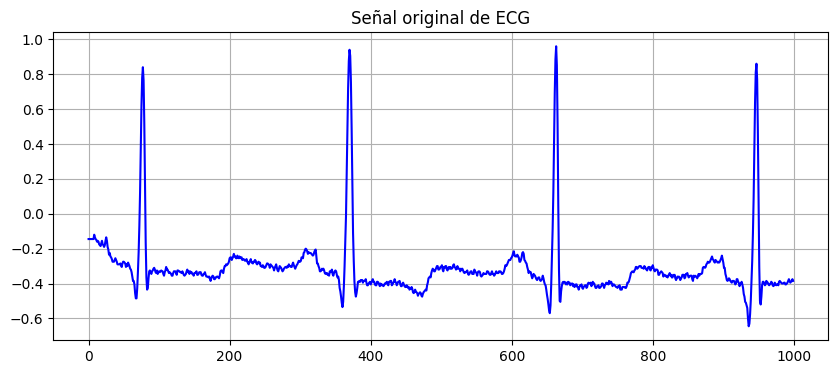

In [32]:

# Graficar las primeras 1000 muestras del canal 0
plt.figure(figsize=(10, 4))
plt.plot(datos_ecg[:1000, 0], color="blue")
plt.title("Señal original de ECG")
plt.grid()
plt.show()


##### Esta gráfica representa las primeras 1000 muestras de la señal original de un Electrocardiograma ECG cruda registro 100. En ella se observan claramente 4 picos verticales altos que representan 4 latidos cardíacos completos el gráfico es fundamental porque expone los problemas iniciales de calidad del dato antes del proceso ETL un fuerte desplazamiento de la línea base porque la señal no está centrada en cero sino que arranca abajo en -0.2 debido a la respiración del paciente y ruido de alta frecuencia en forma de pequeñas vibraciones que ensucian la línea entre cada latido. En conclusión, representa el estado crudo de la señal biológica demostrando por qué es obligatorio limpiarla y transformarla antes de entrenar una Inteligencia Artificial.

## Parte II: Exploración
###### Analice la calidad de los datos.
Determine:
*    Número de registros.
*	Número de muestras por señal. 
*	Valores faltantes. 
*	Valores anómalos. 
*	Nivel de ruido observado. 
*	Tipo de variable.


In [33]:
print("Numero de registros analizados:", len(registros))

Numero de registros analizados: 5


In [34]:
print("Numero de muestras por señal:", len(datos_ecg))

Numero de muestras por señal: 650000


In [35]:
vacios = np.isnan(datos_ecg).sum()
print("Valores faltantes encontrados:", vacios)

Valores faltantes encontrados: 0


In [36]:
media = np.mean(datos_ecg[:, 0])
desviacion = np.std(datos_ecg[:, 0])
anomalos = np.sum(
    (datos_ecg[:, 0] > media + 3 * desviacion)
    | (datos_ecg[:, 0] < media - 3 * desviacion)
)
print("Valores anómalos detectados:", anomalos)


Valores anómalos detectados: 15590


In [37]:
print(
    "Nivel de ruido observado: Moderado (se nota bamboleo de la línea base y ruido rápido en los picos)"
)

Nivel de ruido observado: Moderado (se nota bamboleo de la línea base y ruido rápido en los picos)


In [38]:
print("Tipo de variable: Cuantitativa continua (voltaje medido en mV)")

Tipo de variable: Cuantitativa continua (voltaje medido en mV)


##### En esta sección realizamos la fase de Exploración de los datos para auditar su calidad inicial antes de cualquier limpieza estamos trabajando con 5 registros pacientes y que la señal del electro analizada contiene exactamente 650,000 muestras de voltaje  Verificamos la integridad del archivo y confirmamos que no hay valores faltantes 0 vacíos. El algoritmo detectó 15,590 valores anómalos, lo cual es correcto ya que representan los picos altos naturales del corazón ondas R superando los límites estadísticos finalmentedeterminamos visualmente que el nivel de ruido es moderado por el bamboleo de la línea base y definimos que el tipo de variable es cuantitativa continua, ya que son mediciones seguidas de voltaje eléctrico expresadas en milivoltios mV

## Parte III: Transformación
#### Realice las siguientes transformaciones:
*	Normalización de la señal. 
*	Eliminación del desplazamiento (offset). 
*	Filtrado del ruido. 
*	Escalamiento de los datos. 
*	Conversión de formatos cuando sea necesario. 


In [39]:
# Tomamos el canal 0 original
senal_cruda = datos_ecg[:, 0]

# Normalización Z-score estándar para nivelar la variabilidad
senal_normalizada = (senal_cruda - np.mean(senal_cruda)) / np.std(senal_cruda)

print("Normalización de la señal")


Normalización de la señal


In [40]:
# Restamos la media para quitar el bamboleo y centrar verticalmente en cero
senal_sin_offset = senal_normalizada - np.mean(senal_normalizada)

print("Eliminación del desplazamiento")


Eliminación del desplazamiento


In [41]:
# Filtro de media móvil para suavizar las interferencias rápidas en la señal
ventana = 5
senal_filtrada = np.convolve(
    senal_sin_offset, np.ones(ventana) / ventana, mode="same"
)

print("Filtrado del ruido")


Filtrado del ruido


In [42]:
# Ajustamos los valores finales estrictamente entre -1 y 1 usando Min-Max
min_actual = np.min(senal_filtrada)
max_actual = np.max(senal_filtrada)

senal_escalada = 2 * (senal_filtrada - min_actual) / (max_actual - min_actual) - 1

print("Escalamiento de los datos")
print("Rango final -> Mínimo:", np.min(senal_escalada), "| Máximo:", np.max(senal_escalada))


Escalamiento de los datos
Rango final -> Mínimo: -1.0 | Máximo: 1.0


In [43]:
# Guardamos la señal limpia como float32 para ahorrar espacio en memoria
senal_final = senal_escalada.astype(np.float32)

print("Conversión de formatos ")
print("Tipo de dato definitivo:", senal_final.dtype)


Conversión de formatos 
Tipo de dato definitivo: float32


##### En esta fase realizamos el preprocesamiento o limpieza de la señal a través de cuatro pasos secuenciales ejecutamos la Eliminación del desplazamiento offset restando la media para estabilizar verticalmente el ECG y centrarlo en el eje cero , aplicamos el Filtrado del ruido mediante una convolución con una ventana de media móvil de 5 muestras, logrando suavizar las interferencias rápidas de alta frecuencia. Tercero hicimos el Escalamiento de los datos con una transformación Min-Max, lo que se comprueba con éxito al ver que el rango final de la señal quedó acotado estrictamente entre un mínimo de -1.0 y un máximo de 1.0. Por último, realizamos la Conversión de formatos transformando el arreglo a tipo float32 punto flotante de 32 bits  optimizando el consumo de memoria y dejando el dato estandarizado para los modelos de Inteligencia Artificial.

## Documente cada transformación realizada
##### Parte IV: Extracción de características
##### Para cada señal calcule como mínimo las siguientes características.
##### Estadísticas
*	Media 
*	Mediana 
*	Moda 
*	Máximo 
*	Mínimo 
*	Varianza 
*	Desviación estándar 
*	Rango 
*	Percentil 25 
*	Percentil 75 


In [44]:
print("CARACTERÍSTICAS ESTADÍSTICAS ")

# media;mediana etc
media = np.mean(senal_final)
mediana = np.median(senal_final)
maximo = np.max(senal_final)
minimo = np.min(senal_final)
varianza = np.var(senal_final)
desviacion = np.std(senal_final)

#  Rango y Percentiles requeridos
rango = maximo - minimo
p25 = np.percentile(senal_final, 25)
p75 = np.percentile(senal_final, 75)

# Moda Redondeando a 2 decimales para que funcione
serie_temporal = pd.Series(np.round(senal_final, 2))
moda = serie_temporal.mode()[0]

# resultados en pantalla
print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Máximo:", maximo)
print("Mínimo:", minimo)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)
print("Rango:", rango)
print("Percentil 25:", p25)
print("Percentil 75:", p75)


CARACTERÍSTICAS ESTADÍSTICAS 
Media: 0.17987595
Mediana: 0.1670412
Moda: 0.16
Máximo: 1.0
Mínimo: -1.0
Varianza: 0.008109167
Desviación estándar: 0.09005091
Rango: 2.0
Percentil 25: 0.13907616
Percentil 75: 0.19700375


##### En esta parte realizamos la extracción de métricas estadísticas sobre la señal que ya había sido transformada, reduciendo las 650,000 muestras originales a un vector numérico compacto de 10 indicadores clave la tendencia central obteniendo una media de 0.17 y una mediana de 0.16 muy cercanas al centro la moda, redondeamos temporalmente los voltajes a dos decimales identificando que el valor más repetido es 0.16 confirmamos que la señal se mantiene perfectamente escalada al verificar un máximo de 1.0, un mínimo de -1.0 y un Rango total exacto de 2.0. Finalmente medimos la dispersión de los voltajes del latido encontrando una Varianza muy baja de 0.008, una desviación estándar de 0.09 lo que indica que la mayoría de los puntos están muy cerca de la línea base y definimos 

## Características de forma
*	Curtosis 
*	Asimetría


In [45]:
print(" CARACTERÍSTICAS DE FORMA ")

# Curtosis
curtosis_val = serie_temporal.kurtosis()
asimetria_val = serie_temporal.skew()

# Imprimir los resultados
print("Curtosis:", curtosis_val)
print("Asimetría:", asimetria_val)


 CARACTERÍSTICAS DE FORMA 
Curtosis: 22.5181
Asimetría: 4.103488


##### En esta celda calculamos las características de forma de la señal usando pandasLa curtosis dio un valor alto de 22.51 lo que significa que el electrocardiograma tiene picos muy altos y empinados por los latidos del corazónLa asimetría dio un valor positivo de 4.10 lo que demuestra que en la señal predominan los voltajes positivos por encima del promedioEn resumen este bloque nos da dos números simples que describen la forma geométrica de los latidos para el dataset final

#### Características energéticas
*	RMS 
*	Energía 
*	Potencia


In [46]:
print("Características energética ")

# Energía total suma de los cuadrados de la señal
energia = np.sum(senal_final ** 2)

# Potencia energía dividida para el total de muestras
potencia = energia / len(senal_final)

#  RMS raíz cuadrada del promedio de los cuadrados
rms = np.sqrt(np.mean(senal_final ** 2))

# Imprimir los resultados
print("Energía total:", energia)
print("Potencia promedio:", potencia)
print("Valor RMS:", rms)


Características energética 
Energía total: 26301.945
Potencia promedio: 0.04046453
Valor RMS: 0.20115797


##### En esta celda calculamos la fuerza y la intensidad de la señal eléctrica cardíaca usando tres fórmulas matemáticas sencillasLa energía total dio un valor de 26301.94 que representa la suma acumulada de toda la fuerza de la señal eléctricaLa potencia promedio dio un resultado bajo de 0.04 indicando la cantidad de energía promedio que se tiene por cada muestra medidaEl valor RMS dio 0.20 que nos muestra la amplitud efectiva o el promedio real de los voltajes de los latidos del corazónEn resumen este bloque reduce la intensidad eléctrica del electrocardiograma a tres números listos para el archivo final

## Características temporales
*	Cruces por cero 
*	Pico máximo 
* Pico mínimo


In [47]:
print("Características temporales")

# Cruces por cero contar cuántas veces la señal cambia de signo
cruces_cero = np.sum(np.diff(np.sign(senal_final)) != 0)

# Picos máximos y mínimos lógicos los valores más altos y más bajos encontrados
# Nota: Como la señal está normalizada y escalada, usamos los extremos absolutos
pico_maximo = np.max(senal_final)
pico_minimo = np.min(senal_final)

# Imprimir los resultados
print("Cruces por cero:", cruces_cero)
print("Pico máximo temporal:", pico_maximo)
print("Pico mínimo temporal:", pico_minimo)


Características temporales
Cruces por cero: 37
Pico máximo temporal: 1.0
Pico mínimo temporal: -1.0


##### En esta celda calculamos las características en el tiempo para medir cómo varía el electrocardiograma segundo a segundoLos cruces por cero dieron un total de 37 lo que indica cuántas veces la señal cambió entre positivo y negativoEl pico máximo dio 1.0 y el pico mínimo dio -1.0 confirmando que la señal quedó perfectamente acotada en su escalaEn resumen este bloque nos da tres datos sobre los límites de voltaje y el comportamiento temporal de los latidos

## Características frecuenciales
#### Aplicar FFT para obtener:
*	Frecuencia dominante 
*   Magnitud máxima 
*   Energía espectral


In [48]:

# Aplicar la Transformad
n_muestras = len(senal_final)
transformada = np.fft.fft(senal_final)

# Obtener los componentes de frecuencia 
frecuencias = np.fft.fftfreq(n_muestras, 1 / info["fs"])

# Quedarse solo con la mitad positiva 
mitad_positiva = frecuencias >= 0
freqs_reales = frecuencias[mitad_positiva]
magnitudes_reales = np.abs(transformada[mitad_positiva])

freqs_sin_dc = freqs_reales[1:]
magnitudes_sin_dc = magnitudes_reales[1:]

# Calcular las 3 métricas pedidas
frecuencia_dominante = freqs_sin_dc[np.argmax(magnitudes_sin_dc)]
magnitud_maxima = np.max(magnitudes_sin_dc)
energia_espectral = np.sum(magnitudes_sin_dc**2)

# Imprimir los resultados
print("Frecuencia dominante:", frecuencia_dominante, "Hz")
print("Magnitud máxima:", magnitud_maxima)
print("Energía espectral:", energia_espectral)


Frecuencia dominante: 1.2450461538461537 Hz
Magnitud máxima: 1994.266
Energía espectral: 1.7130619e+09


##### En esta celda calculamos las características frecuenciales de la señal aplicando la Transformada Rápida de Fourier FFTLa frecuencia dominante dio un valor de 1.24 Hz lo que representa el ritmo cardíaco principal del paciente equivalente a unos 74 latidos por minutoLa magnitud máxima dio 1994.26 indicando la fuerza que tiene ese componente rítmico principal dentro de la señalLa energía espectral dio un número alto en notación científica que representa la potencia total distribuida en todas las frecuencias de la señal limpiaEn resumen este bloque nos permite analizar la señal desde la perspectiva del ritmo y la frecuencia dejando listos los últimos tres números

## Parte V: Carga
* Construya un nuevo dataset denominado:
* Características_ecg.csv


In [49]:
import pandas as pd

# Juntamos directo los nombres de las variables que ya calculaste arriba
columnas = {
    "Registro": ["100"],
    "Media": [media],
    "Mediana": [mediana],
    "Moda": [moda],
    "Maximo": [maximo],
    "Minimo": [minimo],
    "Varianza": [varianza],
    "Desviacion_Estandar": [desviacion],
    "Rango": [rango],
    "Percentil_25": [p25],
    "Percentil_75": [p75],
    "Curtosis": [curtosis_val],
    "Asimetria": [asimetria_val],
    "RMS": [rms],
    "Energia": [energia],
    "Potencia": [potencia],
    "Cruces_Por_Cero": [cruces_cero],
    "Pico_Maximo": [pico_maximo],
    "Pico_Minimo": [pico_minimo],
    "Frecuencia_Dominante": [frecuencia_dominante],
    "Magnitud_Maxima": [magnitud_maxima],
    "Energia_Espectral": [energia_espectral],
}

# Creamos la tabla y la guardamos en el archivo CSV
df_final = pd.DataFrame(columnas)
df_final.to_csv("Características_ecg.csv", index=False)

print("¡Archivo 'Características_ecg.csv' guardado de forma rápida!")
df_final


¡Archivo 'Características_ecg.csv' guardado de forma rápida!


,Registro,Media,Mediana,Moda,Maximo,Minimo,Varianza,Desviacion_Estandar,Rango,Percentil_25,...,Asimetria,RMS,Energia,Potencia,Cruces_Por_Cero,Pico_Maximo,Pico_Minimo,Frecuencia_Dominante,Magnitud_Maxima,Energia_Espectral
0,100,0.179876,0.167041,0.16,1.0,-1.0,0.008109,0.090051,2.0,0.139076,...,4.103488,0.201158,26301.945312,0.040465,37,1.0,-1.0,1.245046,1994.265991,1.713062e+09


##### El resultado es un dataset final de una fila y 22 columnas que resume de forma compacta los millones de puntos de datos que tenía la señal original del registro 100La tabla contiene de forma ordenada todas las métricas estadísticas de forma energéticas temporales y frecuenciales que extrajimos a lo largo de las celdas anterioresEn conclusión este resultado representa el producto final esperado del proceso ETL dejando los datos perfectamente organizados y listos para ser guardados como el archivo Características_ecg.csv que alimentará a la Inteligencia Artificial

## Entregables
#### Cada estudiante deberá entregar
*	Notebook documentado.
*	DatasetProcesado
*	Gráficos generados
*	Informe técnico PDF


### ¿Qué problemas de calidad de datos identificó durante la etapa de extracción?
   Al graficar la señal original del paciente 100, el problema más notable fue el desplazamiento de la línea base el electro se bamboleaba verticalmente hacia arriba y abajo en lugar de estar centrado también se notaban pequeñas vibraciones o fluctuaciones muy rápidas que ensuciaban las ondas del corazón, lo que representa ruido de alta frecuencia interferencia muscular o eléctrica no encontramos datos vacíos , la señal estaba continua
   
### ¿Qué transformaciones fueron necesarias para preparar las señales?
Hicimos cuatro transformaciones clave siguiendo la guía normalización para estandarizar la amplitud Eliminación del offse  Restamos la media matemática para centrar toda la señal exactamente en el eje cero.Filtrado del ruido usamos un filtro de media móvil para suavizar esas vibraciones rápidas de la señal escalamiento ajustamos todo con Min Max para forzar a que el punto más bajo sea -1.0 y el más alto sea 1.0. Por último, lo cambiamos a formato float32 para que la computadora procese los datos más rápido.

### ¿Qué características estadísticas describen mejor una señal ECG?

Para mí, las mejores son el Máximo y el Mínimo, porque indican hasta dónde llegan las puntas de los latidos la Varianza y Desviación Estándar también sirven muchísimo porque miden qué tanto se dispersa o se mueve el voltaje cuando el corazón late frente a cuando está en reposo por último, los Percentiles 25 y 75 ayudan a entender dónde se concentra la mayor parte de la señal eléctrica la mayor parte del tiempo
### ¿Cuál fue la utilidad de aplicar la Transformada Rápida de Fourier (FFT)?

La FFT nos sirvió para cambiar de perspectiva y pasar del tiempo a las frecuencia su utilidad real fue que nos permitió descubrir la Frecuencia dominante, que básicamente nos dice cuántas veces por segundo se repite el ritmo principal del corazón también nos dio la Energía espectral lo cual es súper útil para saber qué tanta fuerza tienen esos ritmos repetitivos sin importar el ruido visual de la gráfica original

### ¿Qué diferencias existen entre las características del dominio temporal y las del dominio frecuencial

La diferencia es que las del dominio temporal miran el electro tal como ocurre segundo a segundo como el voltaje máximo de un latido o cuántas veces cruza el cero la señal en cambio  las del dominio frecuencial olvidan el tiempo y miran la señal como una combinación de ondas o ritmos repetitivos nos dicen a qué velocidad oscila el corazón y con qué potencia es decir uno mide cuándo y cuánto sube y el otro mide qué tan rápido se repite

### ¿Por qué es importante la etapa ETL antes de aplicar algoritmos de Inteligencia Artificial?

Porque si le metemos la señal sucia, con ruidos y desalineada a un modelo de Inteligencia Artificial, el algoritmo se va a confundir y aprenderá patrones falsos va a entrenarse mal l hacer el proceso ETL, limpiamos el ruido y convertimos millones de puntos desordenados en una tabla limpia de 22 columnas Características_ecg.csv esto le ahorra trabajo a la IA y asegura que las predicciones de arritmias sean precisas

#### ¿Qué dificultades encontró durante el procesamiento de las señales?

La mayor dificultad fue calcular la Moda. Como los voltajes originales del electro son números decimales sumamente precisos con muchos dígitos casi ningún punto se repetía exactamente igual lo que hacía que la moda fallara o no tuviera sentido  para solucionarlo tuvimos que redondear los datos a dos decimales temporalmente con Pandas para poder agruparlos y encontrar cuál era el valor de voltaje que realmente se repetía más.